# Paralelização de nós

A ideia é criar estrutura do worflow onde possui etapas de parelização


Para isso, irei usar três nós que representa diferentes LLMs para argumentarem sobre algum 

assunto e irei mandar para
uma LLM final para me dizer qual modelo foi o melhor

### Criando estado do grafo

In [3]:
from typing import TypedDict

class State(TypedDict):
    topico: str
    avaliador1: str
    avaliador2: str
    avaliador3: str
    resposta_final: str

### Criando prompt

In [5]:
SYSTEM_PROMPT = """
Você irá receber um tópico e deverá argumentar sobre ele, falando sobre pontos positivos ou negativos.
Se perguntarem se algo é melhor que outro, você deverá argumentar prós e contras para cada disputa.

-------
Tópico
-------
{topico}
"""

### Criando os nós

In [14]:
from langchain.chat_models import init_chat_model
def avaliador1_node(state: State) -> State:
    print("Rodando nó 1")
    topico = state["topico"]
    model = init_chat_model(model="groq:llama-3.3-70b-versatile", temperature=0.5, max_tokens=1000)
    resposta1 = model.invoke(SYSTEM_PROMPT.format(topico=topico))
    return {
        "avaliador1": resposta1.content
    }

In [15]:
def avaliador2_node(state: State) -> State:
    print("Rodando nó 2")
    topico = state["topico"]
    model = init_chat_model(model="groq:openai/gpt-oss-120b", temperature=0.5, max_tokens=1000)
    resposta2 = model.invoke(SYSTEM_PROMPT.format(topico=topico))
    return {
        "avaliador2": resposta2.content
    }

In [39]:
def avaliador3_node(state: State) -> State:
    print("Rodando nó 3")
    topico = state["topico"]
    model = init_chat_model(model="groq:openai/gpt-oss-20b", temperature=0.5, max_tokens=1000)
    resposta3 = model.invoke(SYSTEM_PROMPT.format(topico=topico))
    return {
        "avaliador3": resposta3.content
    }

In [40]:
FINAL_PROMPT = """
Você irá receber 3 argumentos sobre o tópico: {topico}
Você tem a tarefa de escolher qual dos 3 você achou melhor e escrever o motivo de você ter escolhido.
Você é o melhor avaliador do mundo e irá usar as suas habilidades. Seja conciso e super preciso

ARGUMENTO 1:
{argumento1}

------------
ARGUMENTO 2:
{argumento2}

------------
ARGUMENTO 3:
{argumento3}
"""

In [41]:
from pydantic import BaseModel, Field
from typing import Literal

class OutputFormat(BaseModel):
    """
    Classe que determina como será os campos de saída

    Atributos:
        choice: Literal[1, 2, 3] = "Numeração do argumento escolhido"
        explain: str = "Explicação de ter escolhido a numeração específica"
    """
    choice: Literal[1, 2, 3] = Field(description="Numeração do argumento escolhido")
    explain: str = Field(description="Explicação de ter escolhido a numeração específica")

def avaliador_final_node(state: State) -> State:
    avaliador1 = state["avaliador1"]
    avaliador2 = state["avaliador2"]
    avaliador3 = state["avaliador3"]
    topico = state["topico"]

    model = init_chat_model(model="groq:llama-3.1-8b-instant", temperature=0.5, max_tokens=1000)
    model_with_output = model.with_structured_output(OutputFormat)
    response_final = model_with_output.invoke(
        FINAL_PROMPT.format(
            topico=topico,
            argumento1=avaliador1,
            argumento2=avaliador2,
            argumento3=avaliador3,
        )
    )

    return {"resposta_final": response_final}

### Criando estrutura do grafo

In [42]:
from langgraph.graph import START, END, StateGraph

graph_builder = StateGraph(State)

graph_builder.add_node("avaliador1", avaliador1_node)
graph_builder.add_node("avaliador2", avaliador2_node)
graph_builder.add_node("avaliador3", avaliador3_node)
graph_builder.add_node("avaliador_final", avaliador_final_node)


graph_builder.add_edge(START, "avaliador1")
graph_builder.add_edge(START, "avaliador2")
graph_builder.add_edge(START, "avaliador3")
graph_builder.add_edge("avaliador1", "avaliador_final")
graph_builder.add_edge("avaliador2", "avaliador_final")
graph_builder.add_edge("avaliador3", "avaliador_final")
graph_builder.add_edge("avaliador_final", END)

graph_compiled = graph_builder.compile()

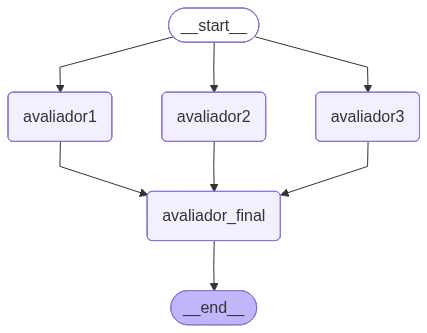

In [43]:
from IPython.display import display, Image

display(Image(graph_compiled.get_graph().draw_mermaid_png()))

In [44]:
state = {
    "topico": "Qual franquia é maior, Los angeles Lakers ou Boston Celtics?"
}

response = graph_compiled.invoke(state)

Rodando nó 1
Rodando nó 2
Rodando nó 3


In [ ]:
response

{'topico': 'Qual franquia é maior, Los angeles Lakers ou Boston Celtics?',
 'avaliador1': 'Que pergunta emocionante! A discussão sobre qual franquia é maior entre Los Angeles Lakers e Boston Celtics é um tópico que gera muita paixão e debate entre os fãs de basquete. Vamos analisar alguns pontos positivos e negativos de cada franquia para tentar responder a essa pergunta.\n\n**Los Angeles Lakers**\n\nPontos positivos:\n\n* **Títulos**: Os Lakers têm 17 títulos da NBA, o que é um número impressionante e um dos maiores da história da liga.\n* **Jogadores lendários**: A franquia contou com jogadores como Kareem Abdul-Jabbar, Magic Johnson, Kobe Bryant e LeBron James, que são considerados alguns dos melhores da história do basquete.\n* **Sucesso recente**: Os Lakers têm sido uma das franquias mais bem-sucedidas nos últimos anos, com títulos em 2000, 2001, 2002, 2009, 2010 e 2020.\n* **Reconhecimento global**: A franquia tem uma grande presença global, com fãs em todo o mundo e uma marca re

In [47]:
response["resposta_final"].choice

2

In [49]:
print(response["resposta_final"].explain)

Escolhi a numeração 2 porque acho que a resposta depende dos critérios que você adotar. Em termos de número de títulos e longevidade, os Celtics têm a vantagem histórica, mas os Lakers têm duas dinastias recentes que reforçam sua imagem de ‘grande franquia’. Além disso, os Lakers são a franquia mais reconhecida mundialmente, graças à localização e às estrelas de Hollywood, enquanto os Celtics têm uma base de fãs extremamente fiel, mas com alcance global ligeiramente menor. Financeiramente, os Lakers lideram em valor de mercado e receitas, mas os Celtics também ocupam posição de elite. Portanto, é difícil dizer qual franquia é maior, pois ambas têm seus pontos fortes e fracos.
